## Read results

In [ ]:
from pathlib import Path
import pandas as pd

MODEL = ["llama-3.1-8b", "qwen3-8b"][0]
SUBSET = ["algorithm-generated", "hand-crafted"][0]
REP_TYPE = "hidden"

base = Path(f"/data/hoang/attrib/results_svd/{REP_TYPE}/")
svd_pattern = f"{MODEL}/metrics/{SUBSET}/svd_*.tsv"
clf_pattern = f"{MODEL}/metrics/{SUBSET}/classifer_*.tsv"

frames = []
for path in sorted(base.glob(svd_pattern)):
    parts = path.stem.split("_")
    pooling = parts[1][len("pooling-"):]
    seed = int(parts[2][len("seed-"):])
    df = pd.read_csv(path, sep="\t").assign(
        pooling=pooling, seed=seed
    )
    frames.append(df)
    
svd_df = pd.concat(frames, ignore_index=True)

frames = []
for path in sorted(base.glob(clf_pattern)):
    parts = path.stem.split("_")
    pooling = parts[1][len("pooling-"):]
    seed = int(parts[2][len("seed-"):])
    df = pd.read_csv(path, sep="\t").assign(
        pooling=pooling, seed=seed
    )
    frames.append(df)
    
clf_df = pd.concat(frames, ignore_index=True)
oracle_df = clf_df.query("labels == 'oracle'")
pseudo_df = clf_df.query("labels == 'pseudo'")

In [ ]:
# from pathlib import Path
# import pandas as pd

# MODEL = ["llama-3.1-8b", "qwen3-8b"][0]
# SUBSET = ["algorithm-generated", "hand-crafted"][0]
# REP_TYPE = "hidden"

# base = Path(f"outputs/2025-05-25/{REP_TYPE}")
# # base = Path(f"/data/hoang/attrib/results_svd/{REP_TYPE}/")
# svd_pattern = f"{MODEL}/metrics/{SUBSET}/svd_*.tsv"

# frames = []
# for path in sorted(base.glob(svd_pattern)):
#     parts = path.stem.split("_")
#     pooling = parts[1][len("pooling-"):]
#     seed = int(parts[2][len("seed-"):])
#     df = pd.read_csv(path, sep="\t").assign(
#         pooling=pooling, seed=seed
#     )
#     frames.append(df)
    
# svd_df = pd.concat(frames, ignore_index=True)


In [12]:
# svd_df.sort_values("step_acc_test", ascending=False)

In [52]:
oracle_df = oracle_df[[
    "threshold", "weight", "pooling", "c", "centered", "direction", "seed",
    "val_step_acc", "val_agent_acc", "test_step_acc", "test_agent_acc"
]]
# print(oracle_df.head().to_string())
idx = (oracle_df.groupby(['pooling', 'seed'])['test_step_acc'].idxmax())
oracle_report = oracle_df.loc[idx].reset_index(drop=True)
oracle_report.loc["average"] = oracle_report.filter(like="_acc").mean()
oracle_report

,threshold,weight,pooling,c,centered,direction,seed,val_step_acc,val_agent_acc,test_step_acc,test_agent_acc
0,0.0,act/17,last,1.0,True,asc,1.0,0.0,0.833333,0.241379,0.551724
1,0.0,act/3,last,17.0,False,asc,2.0,0.0,0.500000,0.275862,0.620690
2,0.0,act/14,last,4.0,True,asc,3.0,0.0,0.333333,0.275862,0.551724
3,0.0,act/33,mean,4.0,False,asc,1.0,0.0,0.666667,0.344828,0.689655
4,0.0,embed,mean,4.0,True,asc,2.0,0.0,0.500000,0.241379,0.689655
5,0.0,act/27,mean,1.0,True,asc,3.0,0.0,0.333333,0.310345,0.551724
average,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.527778,0.281609,0.609195


In [53]:
pseudo_df = pseudo_df[[
    "threshold", "weight", "pooling", "c", "centered", "direction", "seed",
    "val_step_acc", "val_agent_acc", "test_step_acc", "test_agent_acc"
]]
# print(pseudo_df.head().to_string())
idx = (pseudo_df.groupby(['pooling', 'seed'])['test_step_acc'].idxmax())
pseudo_report = pseudo_df.loc[idx].reset_index(drop=True)
pseudo_report

,threshold,weight,pooling,c,centered,direction,seed,val_step_acc,val_agent_acc,test_step_acc,test_agent_acc
0,0.100,act/32,last,13,False,asc,1,0.166667,0.833333,0.275862,0.655172
1,0.020,act/4,last,1,True,asc,2,0.000000,0.333333,0.206897,0.586207
2,0.020,act/31,last,1,True,asc,3,0.000000,0.166667,0.172414,0.551724
3,0.025,act/34,mean,13,False,asc,1,0.333333,0.500000,0.310345,0.689655
4,0.025,act/30,mean,1,True,asc,2,0.000000,0.333333,0.275862,0.689655
5,0.020,act/22,mean,13,False,asc,3,0.166667,0.500000,0.344828,0.586207


## Reproduce best results

In [54]:
import torch
from attribscope.svd2.utils import (
    RepresentationStores,
    load_representations,
    _resolve_dir,
    split_data,
    compute_metrics,
    get_mistake_meta
)
from attribscope.classifier.run_all_positions import (
    prepare_data, precompute_svd, run_one
)
from attribscope.classifier.classifier import (
    seed_everything, MLPClassifier, infer, train
)

REPS_ROOT    = Path("/data/hoang/attrib/outputs")
DATA_ROOT    = Path("data/ww")
WEIGHT_NAMES = "all"
DEVICE       = torch.device("cuda:7")


In [55]:
best_config = pseudo_report.iloc[0].to_dict()
threshold   = best_config["threshold"]
position    = best_config["weight"]
pooling     = best_config["pooling"]
c           = best_config["c"]
centered    = best_config["centered"]
seed        = best_config["seed"]
best_config

{'threshold': 0.1,
 'weight': 'act/32',
 'pooling': 'last',
 'c': 13,
 'centered': False,
 'direction': 'asc',
 'seed': 1,
 'val_step_acc': 0.1666666666666666,
 'val_agent_acc': 0.8333333333333334,
 'test_step_acc': 0.2758620689655172,
 'test_agent_acc': 0.6551724137931034}

In [56]:
rep_dir = _resolve_dir(
    root_dir=REPS_ROOT,
    model=MODEL,
    subset=SUBSET,
    rep_type=REP_TYPE,
    loss=None,
    temperature=None,
    dir_type="representations"
)


data_dir = DATA_ROOT / SUBSET
print(f"Representation dir: {rep_dir}")
print(f"Data dir:           {data_dir}")

files = sorted(rep_dir.glob("*.safetensors"), key=lambda x: int(x.stem))
files = [f.name for f in files]
assert files, (f"No .safetensors files in {rep_dir}")

train_files, test_files = split_data(files, 0.5, seed)
train_files, val_files  = split_data(train_files, 0.8, seed)

print(f"Total train trajectories: {len(train_files)}")
print(f"Total val trajectories:   {len(val_files)}")
print(f"Total test trajectories:  {len(test_files)}")

rep_kwargs = dict(
    rep_dir=rep_dir,
    data_dir=data_dir,
    pooling=pooling,
    weight_names=WEIGHT_NAMES,
    device=DEVICE,
)

train_reps = load_representations(**rep_kwargs, files=train_files)
val_reps   = load_representations(**rep_kwargs, files=val_files)
test_reps  = load_representations(**rep_kwargs, files=test_files)

Representation dir: /data/hoang/attrib/outputs/hidden/qwen3-8b/reps/hand-crafted
Data dir:           data/ww/hand-crafted
Total train trajectories: 23
Total val trajectories:   6
Total test trajectories:  29


Loading representations:   0%|          | 0/23 [00:00<?, ?it/s]

Loading representations: 100%|██████████| 29/29 [00:02<00:00, 11.89it/s]


In [57]:
precomputed_svd = precompute_svd(train_reps, val_reps, test_reps, 
                                    n_components=20, device=DEVICE)

train_scores = precomputed_svd["train_scores"]
val_scores   = precomputed_svd["val_scores"]
svd_accuracy = precomputed_svd["svd_accuracy"]

SVD fit: 100%|██████████| 38/38 [00:01<00:00, 28.80it/s]


In [58]:
mode = "pseudo"
prepared_data = prepare_data(
    train_reps, val_reps, test_reps, train_scores, val_scores,
    layer_idx=position, threshold=threshold, mode=mode, device=DEVICE
)

train_loader = prepared_data["train_loader"]
val_loader   = prepared_data["val_loader"]
X_train, y_train = prepared_data["train"]
X_val, y_val     = prepared_data["validation"]
X_test, y_test   = prepared_data["test"]
best_val_config  = prepared_data["best_config"]

------------------------------------------------------------
Using best validation config:
weight == 'act/32' and pooling == 'last' and method  == 'proj' and c == 13 and centered == False
The best validation results with direct projection on SVD components
Step@1: 0.1667 Agent@1: 0.8333



In [61]:
seed_everything(seed)
clf = MLPClassifier(
    input_dim=X_train.shape[1], 
    hidden_dim=1024
)
clf, metrics = run_one(
    clf, train_loader, val_loader,
    val_reps, test_reps,
    layer_idx = position,
    threshold = threshold,
    epochs = 500,
    learning_rate = 0.02,
    device = DEVICE
)

Epoch 100/500 - loss: 0.0806 | accuracy: 0.8485 | precision: 0.1158 | recall: 0.0803 | F1: 0.0948 | auroc: 0.5074 | val f1: 0.0000 (best: 0.2000)
Epoch 200/500 - loss: 0.0294 | accuracy: 0.8182 | precision: 0.0922 | recall: 0.0949 | F1: 0.0935 | auroc: 0.5320 | val f1: 0.0741 (best: 0.2105)
Epoch 300/500 - loss: 0.0193 | accuracy: 0.8211 | precision: 0.1007 | recall: 0.1022 | F1: 0.1014 | auroc: 0.5336 | val f1: 0.0000 (best: 0.2105)
Epoch 400/500 - loss: 0.0171 | accuracy: 0.8268 | precision: 0.1295 | recall: 0.1314 | F1: 0.1304 | auroc: 0.5286 | val f1: 0.0000 (best: 0.2105)
Epoch 500/500 - loss: 0.0173 | accuracy: 0.8211 | precision: 0.1007 | recall: 0.1022 | F1: 0.1014 | auroc: 0.4619 | val f1: 0.0000 (best: 0.2105)
Load from best state from epoch 135
Best f1: 0.21052631578947367
  Layer     act/32 | Validation Step@1: 0.1667  Agent@1: 0.8333 | Test  Step@1: 0.2759  Agent@1: 0.6552


In [62]:
assert metrics["test_step_acc"] == best_config["test_step_acc"]
print("Successfully reproduce the best results!")

AssertionError: 

In [63]:
metrics["test_step_acc"], best_config["test_step_acc"]

(0.27586206896551724, 0.2758620689655172)

## Score reweighting

In [13]:
%load_ext autoreload
%autoreload 2

In [14]:
import json
from collections import defaultdict
from pathlib import Path
import numpy as np
from attribscope.svd2.utils import StoreKeeper
import torch.nn.functional as F
from safetensors import safe_open

from attribscope.reweight.reweight import (
    load_weighting, process_weighting,
    reweight_scores, compute_metrics,
    resolve_layer
)

In [29]:
MODEL = ["llama-3.1-8b", "qwen3-8b"][0]
SUBSET = ["algorithm-generated", "hand-crafted"][0]
OUTPUT_ROOT = Path(f"outputs/weighting/{MODEL}/{SUBSET}")

In [ ]:
all_weights = load_weighting(MODEL, SUBSET, device=DEVICE)

Loaded 58 trajectories from outputs/weighting/llama-3.1-8b/hand-crafted


In [19]:
sel_weights = process_weighting(
    all_weights, 
    layer=resolve_layer(best_config['weight']), 
    temp=0.1, 
    sim="raw_dot"
)

In [22]:
X_test = test_reps.stores[position].R
test_keeper = test_reps.keeper

X_test = X_test.float().to(DEVICE)
test_scores = infer(clf, X_test, return_logits=False, device=DEVICE)

In [33]:
sel_weights = process_weighting(
    all_weights, 
    layer=resolve_layer(best_config['weight']), 
    temp=1.0, 
    sim="raw_dot"
)

In [35]:
test_mistake_indices, test_mistake_roles   = get_mistake_meta(test_reps.keeper)
# for temp in [0.1, 0.2, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0]:
for temp in [1.0]:
    sel_weights = process_weighting(
        all_weights, 
        layer=resolve_layer(best_config['weight']), 
        temp=temp, 
        sim="raw_dot"
    )
    for g in [0.0, 0.1, 0.3, 0.5, 1.0]:
        r = reweight_scores(test_scores, test_keeper, sel_weights, gamma=g, k=100)
        print(f"gamma={g:.1f} | temp={temp}")
        test_metrics = compute_metrics(
            scores=r, keeper=test_reps.keeper,
            ks=[1], direction="desc",
        )
        print(
            f"step_acc: {test_metrics['step@1_desc']:.4f} | "
            f"agent_acc: {test_metrics['agent@1_desc']:.4f}"
        )

gamma=0.0 | temp=1.0
step_acc: 0.2414 | agent_acc: 0.5517
gamma=0.1 | temp=1.0
step_acc: 0.2069 | agent_acc: 0.5517
gamma=0.3 | temp=1.0
step_acc: 0.1724 | agent_acc: 0.5517
gamma=0.5 | temp=1.0
step_acc: 0.2069 | agent_acc: 0.5517
gamma=1.0 | temp=1.0
step_acc: 0.1724 | agent_acc: 0.5172


In [31]:
best_config

{'threshold': 0.15,
 'weight': 'act/14',
 'pooling': 'mean',
 'c': 16,
 'centered': False,
 'direction': 'asc',
 'seed': 2,
 'val_step_acc': 0.0,
 'val_agent_acc': 0.3333333333333333,
 'test_step_acc': 0.2413793103448276,
 'test_agent_acc': 0.5517241379310345}

In [50]:
import pandas as pd
from pathlib import Path

MODEL  = ["llama-3.1-8b", "qwen3-8b"][1]
SUBSET = ["algorithm-generated", "hand-crafted"][1]

df = pd.read_csv(
    Path(f"outputs/reweighted_results/{MODEL}/{SUBSET}/reweight_sweep.tsv"),
    sep="\t",
)

# Each (mode, threshold, weight, pooling, c, centered, seed) tuple is one original
# config; we want the (gamma, k) row that maximizes step_acc within each tuple.
config_cols = ["mode", "threshold", "weight", "pooling", "c", "centered", "seed"]

best = df.loc[df.groupby(config_cols)["step_acc"].idxmax()].reset_index(drop=True)

# Lift over the no-reweighting baseline
best["step_lift"]  = best["step_acc"]  - best["baseline_step_acc"]
best["agent_lift"] = best["agent_acc"] - best["baseline_agent_acc"]

best = best[config_cols + [
    "gamma", "k",
    # "baseline_step_acc", "step_lift",
    # "baseline_agent_acc", "agent_lift", 
    "baseline_step_acc", "baseline_agent_acc",
    "step_acc", "agent_acc"
]].sort_values(["mode", "pooling", "seed"], ascending=[False, True, True]).reset_index(drop=True)

# print(best.to_string(index=False))
# print("\nMean lift by mode:")
# print(best.groupby("mode")[["step_lift", "agent_lift"]].mean().round(4))
best.to_csv("outputs/temps/temp.tsv", sep="\t", index=False)

In [40]:
best

,mode,threshold,weight,pooling,c,centered,seed,gamma,k,baseline_step_acc,step_acc,step_lift,baseline_agent_acc,agent_acc,agent_lift
0,oracle,0.000,act/16,last,2,True,1,0.1,1,0.507937,0.507937,0.000000,0.730159,0.730159,0.000000
1,oracle,0.000,act/9,last,6,True,2,0.5,2,0.460317,0.476190,0.015873,0.682540,0.730159,0.047619
2,oracle,0.000,act/21,last,1,True,3,0.1,1,0.539683,0.539683,0.000000,0.650794,0.650794,0.000000
3,oracle,0.000,act/31,mean,17,True,1,0.5,3,0.492063,0.523810,0.031746,0.619048,0.619048,0.000000
4,oracle,0.000,act/31,mean,6,False,2,0.1,1,0.460317,0.460317,0.000000,0.619048,0.619048,0.000000
5,oracle,0.000,act/31,mean,7,True,3,0.1,2,0.523810,0.539683,0.015873,0.650794,0.666667,0.015873
6,pseudo,0.025,act/26,last,4,True,1,0.2,2,0.428571,0.444444,0.015873,0.571429,0.571429,0.000000
7,pseudo,0.150,act/14,last,2,True,2,0.1,1,0.428571,0.412698,-0.015873,0.555556,0.571429,0.015873
8,pseudo,0.010,act/12,last,3,True,3,0.1,1,0.396825,0.396825,0.000000,0.555556,0.539683,-0.015873
9,pseudo,0.050,act/31_normed,mean,14,True,1,0.2,1,0.396825,0.412698,0.015873,0.555556,0.571429,0.015873


## Plot scores

In [67]:
val_mistake_indices, val_mistake_roles     = get_mistake_meta(val_reps.keeper)
test_mistake_indices, test_mistake_roles   = get_mistake_meta(test_reps.keeper)

X_test = test_reps.stores[position].R
X_test = X_test.float().to(DEVICE)
test_scores = infer(clf, X_test, return_logits=False, device=DEVICE)
test_metrics = compute_metrics(
    scores=test_scores, keeper=test_reps.keeper,
    mistake_indices=test_mistake_indices, mistake_roles=test_mistake_roles,
    ks=[1], direction="desc",
)
test_step_acc, test_agent_acc = list(test_metrics.values())

In [69]:
sum(test_scores > 0.5)

tensor(150, device='cuda:7')

In [70]:
from itertools import groupby
import matplotlib.pyplot as plt

def plot_scores(scores_by_traj, idxs_by_traj):
    fig, ax = plt.subplots(figsize=(12, 4))

    x = list(range(len(scores_by_traj)))
    colors = ['red' if idx.is_mistake else 'steelblue' for idx in idxs_by_traj]

    ax.plot(x, scores_by_traj, color='gray', zorder=1)
    ax.scatter(x, scores_by_traj, c=colors, zorder=2, s=60)

    for i, (score, idx) in enumerate(zip(scores_by_traj, idxs_by_traj)):
        label = f"{idx.role}\nstep={idx.step_idx} mistake={idx.is_mistake}"
        ax.annotate(label, (i, score), textcoords="offset points",
                    xytext=(0, 10), ha='center', fontsize=7, color=colors[i])

    ax.set_xticks(x)
    plt.tight_layout()
    plt.show()
    
def get_traj_scores(scores, grouped_idxs, traj_idx):
    rows = [idx.row for idx in grouped_idxs[traj_idx]]
    return scores[rows]

grouped_idxs = {
    traj_idx: list(items) for traj_idx, items 
    in groupby(test_reps.keeper.index, key=lambda x: x.traj_idx)
}
traj_idxs = sorted(grouped_idxs.keys())



In [71]:
import numpy as np
from collections import defaultdict

def classify_traj(scores, grouped_idxs, traj_idx):
    idxs = grouped_idxs[traj_idx]
    traj_scores = get_traj_scores(scores, grouped_idxs, traj_idx)
    
    max_score = traj_scores.max().item()
    mistake_scores = [traj_scores[i].item() for i, idx in enumerate(idxs) if idx.is_mistake]
    
    return any(s == max_score for s in mistake_scores)

def get_all_mistake_windows(scores, grouped_idxs, traj_idxs, window=2):
    position_scores = defaultdict(list)
    
    for traj_idx in traj_idxs:
        idxs = grouped_idxs[traj_idx]
        traj_scores = get_traj_scores(scores, grouped_idxs, traj_idx)
        mistake_positions = [i for i, idx in enumerate(idxs) if idx.is_mistake]
        
        for pos in mistake_positions:
            start, end = max(0, pos - window), min(len(idxs), pos + window + 1)
            for i in range(start, end):
                rel_pos = i - pos
                position_scores[rel_pos].append(traj_scores[i].item())
    
    return position_scores

def plot_aggregated_mistake_windows(scores, grouped_idxs, traj_idxs, window=2):
    position_scores = get_all_mistake_windows(scores, grouped_idxs, traj_idxs, window)
    
    positions = sorted(position_scores.keys())
    means = [np.mean(position_scores[p]) for p in positions]
    stds  = [np.std(position_scores[p])  for p in positions]
    counts = [len(position_scores[p])    for p in positions]
    
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(positions, means, marker='o', color='steelblue')
    ax.fill_between(positions,
                    np.array(means) - np.array(stds),
                    np.array(means) + np.array(stds),
                    alpha=0.3, color='steelblue')
    
    ax.axvline(0, color='red', linestyle='--', label='mistake step')
    for p, m, n in zip(positions, means, counts):
        ax.annotate(f'n={n}', (p, m), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8)
    
    ax.set_xlabel('Position relative to mistake')
    ax.set_ylabel('Score')
    ax.set_xticks(positions)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [72]:
def classify_trajs(scores, grouped_idxs, traj_idxs):
    group1, group2 = [], []
    for traj_idx in traj_idxs:
        idxs = grouped_idxs[traj_idx]
        traj_scores = get_traj_scores(scores, grouped_idxs, traj_idx)
        max_score = traj_scores.max().item()
        mistake_scores = [traj_scores[i].item() for i, idx in enumerate(idxs) if idx.is_mistake]
        (group1 if max_score in mistake_scores else group2).append(traj_idx)
    return group1, group2

def plot_group(ax, scores, grouped_idxs, traj_idxs, window, color, label):
    position_scores = get_all_mistake_windows(scores, grouped_idxs, traj_idxs, window)
    positions = sorted(position_scores.keys())
    means = [np.mean(position_scores[p]) for p in positions]
    stds  = [np.std(position_scores[p])  for p in positions]
    counts = [len(position_scores[p])    for p in positions]
    
    ax.plot(positions, means, marker='o', color=color, label=label)
    ax.fill_between(positions, np.array(means)-np.array(stds),
                    np.array(means)+np.array(stds), alpha=0.2, color=color)
    for p, m, n in zip(positions, means, counts):
        ax.annotate(f'n={n}', (p, m), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8)

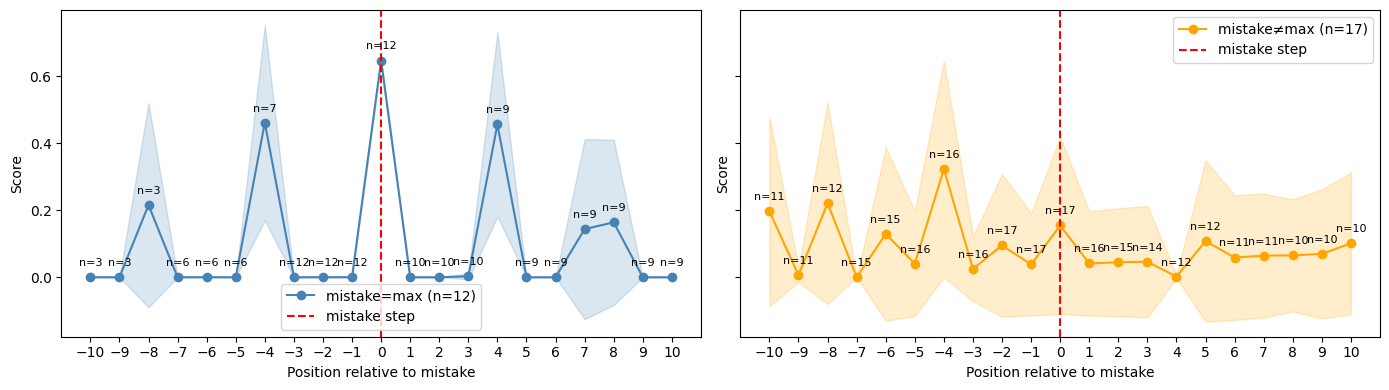

In [73]:
group1, group2 = classify_trajs(test_scores, grouped_idxs, traj_idxs)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
window_size = 10

for ax, traj_group, color, label in [
    (axes[0], group1, 'steelblue', f'mistake=max (n={len(group1)})'),
    (axes[1], group2, 'orange',    f'mistake≠max (n={len(group2)})')
]:
    
    plot_group(ax, test_scores, grouped_idxs, traj_group, window=window_size, color=color, label=label)
    ax.axvline(0, color='red', linestyle='--', label='mistake step')
    ax.set_xlabel('Position relative to mistake')
    ax.set_ylabel('Score')
    ax.set_xticks(list(range(-window_size, window_size+1)))
    ax.legend()

plt.tight_layout()
plt.show()

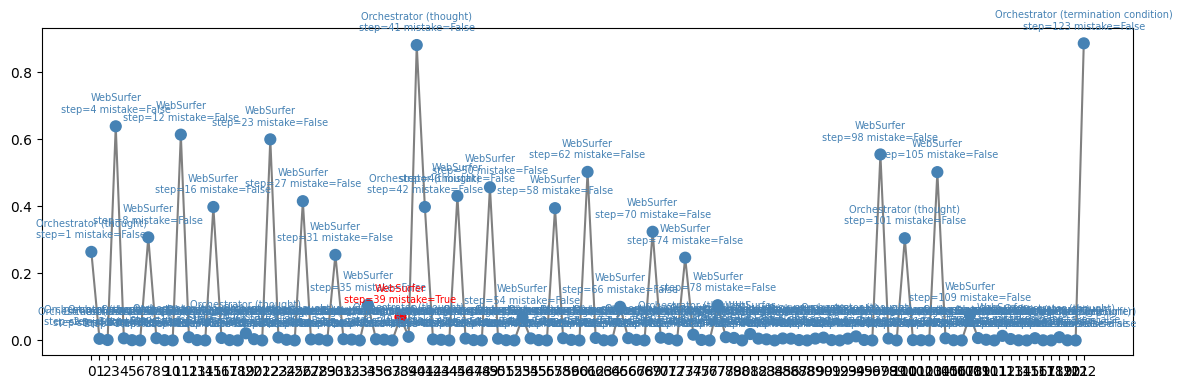

In [35]:
traj_idx = group2[16]
scores_by_traj = get_traj_scores(
    test_scores, 
    grouped_idxs, 
    traj_idx=traj_idx
).cpu().numpy()
idxs_by_traj = grouped_idxs[traj_idx]

plot_scores(scores_by_traj, idxs_by_traj)

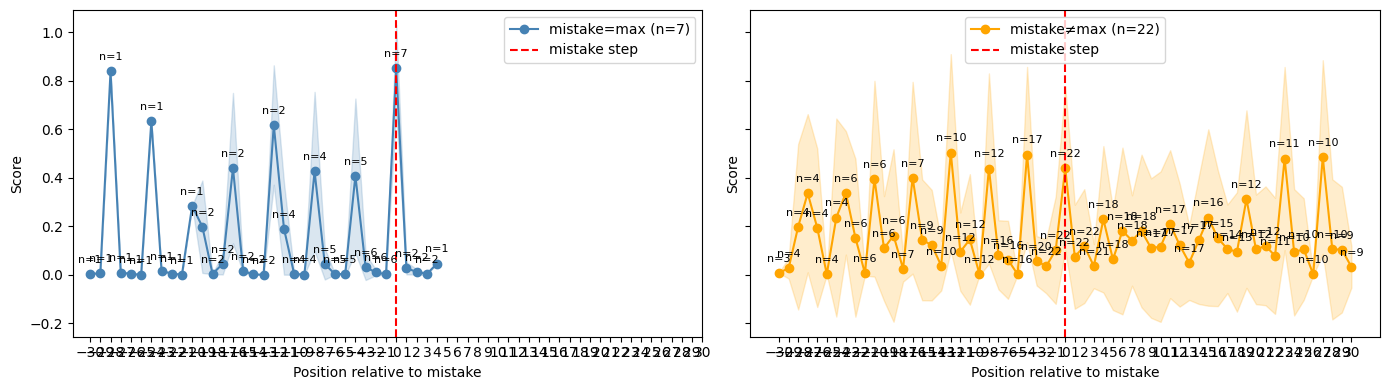

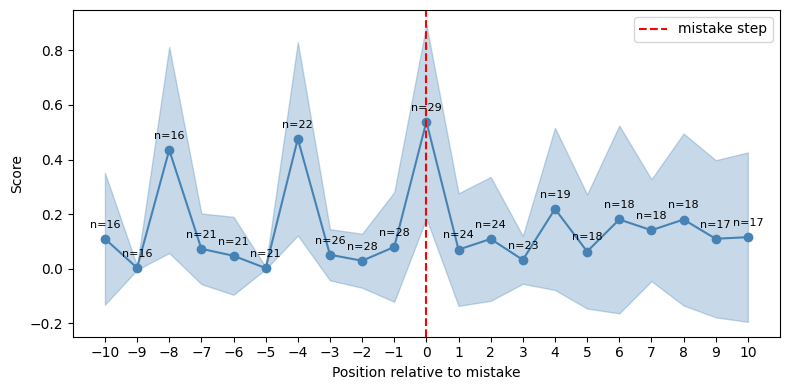

In [77]:
plot_aggregated_mistake_windows(
    scores=test_scores,
    grouped_idxs=grouped_idxs,
    traj_idxs=traj_idxs,
    window=10
)